In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. VERİ YÜKLEME VE DOĞAL DİL İŞLEME
# ==========================================
print("1. Yeni X (Twitter) veri seti yükleniyor...")
csv_file_path = 'Hate and offensive speech detection.csv' 

df = pd.read_csv(csv_file_path)

# --- SÜTUN İSMİ KONTROLÜ VE OTOMATİK DÜZELTME ---
username_col = 'username'
tweet_col = 'tweet'
label_col = 'label'

print(f"Kullanılan sütunlar -> Tweet: '{tweet_col}', Label: '{label_col}'")

# Veri setindeki çoklu etiketleri İkili (Binary) formata dönüştürüyoruz:
# 1 (Nefret) ve 2 (Saldırgan) -> 1 (Siber Zorbalık)
# 3 (Normal) -> 0 (Zorbalık Yok)
df['target_label'] = df[label_col].map({1.0: 1, 2.0: 1, 3.0: 0, 1: 1, 2: 1, 3: 0})

# Boş (NaN) satırlar varsa temizliyoruz
df = df.dropna(subset=[tweet_col, 'target_label'])

tweets = df[tweet_col].astype(str).values
labels = df['target_label'].values

# Hiperparametreler: En sık kullanılan 10.000 kelime alınacak, her tweet 100 kelimeyle sınırlandırılacak
max_features = 10000 
maxlen = 100         

print("2. Tokenization ve Padding işlemleri yapılıyor...")
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(tweets) # Kelime dağarcığını (vocabulary) oluştur
X_sequences = tokenizer.texts_to_sequences(tweets) # Kelimeleri sayısal indekslere çevir
# Vektör matrislerinin boyutlarının aynı olması için kısa cümlelerin sonuna 0 (pad) eklenir
X_padded = pad_sequences(X_sequences, maxlen=maxlen)

# Veriyi %80 Eğitim ve %20 Test olacak şekilde rastgele ikiye ayırıyoruz
x_train, x_test, y_train, y_test = train_test_split(X_padded, labels, test_size=0.2, random_state=42)
# ==========================================
# 2. RNN / LSTM MODEL MİMARİSİ
# ==========================================
print("\n3. Metin Analizine Uygun LSTM Mimarisi Kuruluyor...")
model = Sequential([
    # Embedding: Kelimelerin birbiriyle olan anlamsal ilişkisini 64 boyutlu yoğun vektör uzayında temsil eder
    Embedding(max_features, 64, input_length=maxlen),

    # SpatialDropout1D: Standart dropout'tan farklı olarak, kelimeler arasındaki yapısal bağı koparmamak için 
    # 1 boyutlu özellik haritalarını rastgele tümden kapatarak ezberlemeyi engeller
    SpatialDropout1D(0.3), 

    # LSTM Katmanı: Önceki kelimeleri hafızada tutarak cümlenin genel niyetini/bağlamını (context) öğrenir
    LSTM(32, return_sequences=False),
    Dropout(0.5), # Ağırlıkların yarısını kapatarak genelleme yeteneğini artırır
    # Çıktı Katmanı: İkili sınıflandırma (0 veya 1) olduğu için Sigmoid aktivasyonu kullanılır
    Dense(1, activation='sigmoid')
])

1. Yeni X (Twitter) veri seti yükleniyor...
Kullanılan sütunlar -> Tweet: 'tweet', Label: 'label'
2. Tokenization ve Padding işlemleri yapılıyor...

3. Metin Analizine Uygun LSTM Mimarisi Kuruluyor...


C:\Users\alien\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [2]:
# Modelin Derlenmesi: İkili problem nedeniyle 'binary_crossentropy' kullanılmıştır
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# ==========================================
# 3. MODEL EĞİTİMİ
# ==========================================
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

print("\n4. Model Eğitimi Başlıyor (X Örüntüleri Çözülüyor)...")
history = model.fit(
    x_train, y_train,
    batch_size=128, # Metin verilerinde matris işlemleri daha hafif olduğu için batch_size yüksek tutulmuştur
    epochs=6, 
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)


4. Model Eğitimi Başlıyor (X Örüntüleri Çözülüyor)...
Epoch 1/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - accuracy: 0.6542 - loss: 0.6221 - val_accuracy: 0.7244 - val_loss: 0.5519
Epoch 2/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7838 - loss: 0.4629 - val_accuracy: 0.7549 - val_loss: 0.4991
Epoch 3/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.8392 - loss: 0.3711 - val_accuracy: 0.7568 - val_loss: 0.5295
Epoch 4/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.8690 - loss: 0.3163 - val_accuracy: 0.7449 - val_loss: 0.5801
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.



RAPOR BİLEŞENLERİ VE ANALİZLER HAZIRLANIYOR


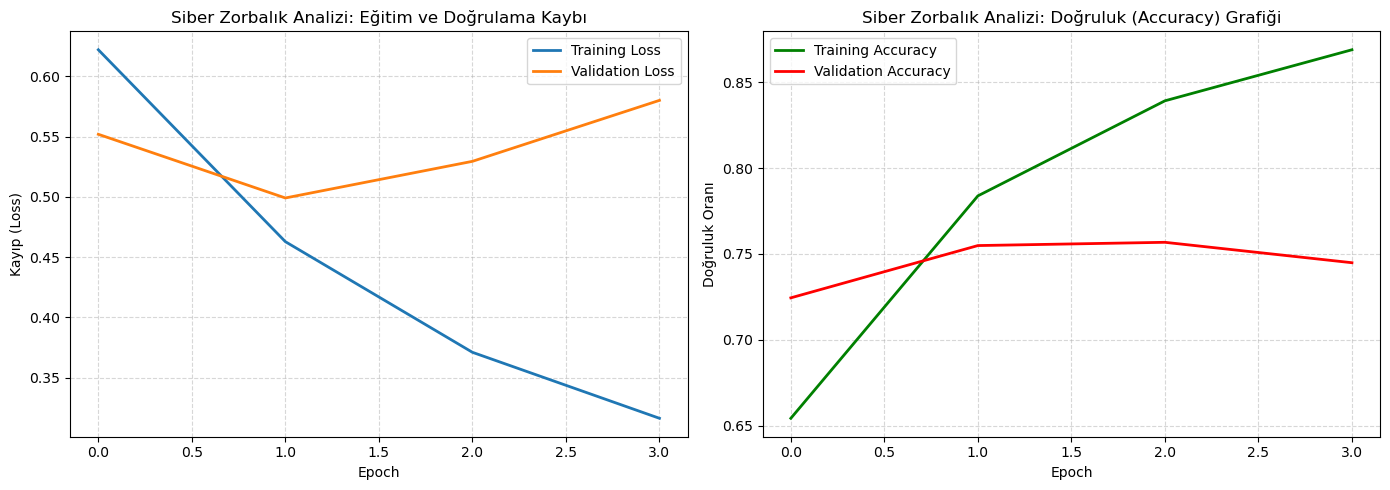

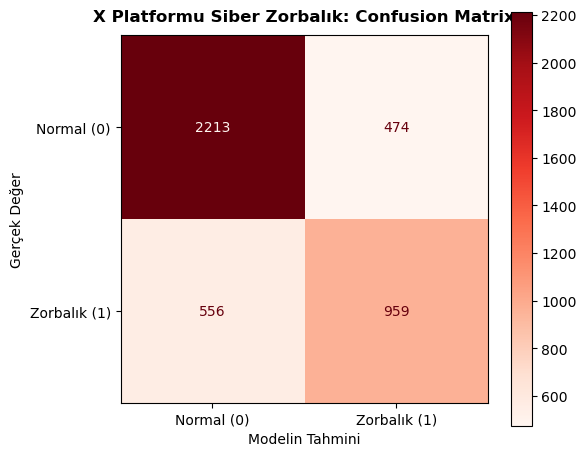


--- PERFORMANS METRİKLERİ RAPORU ---
                         precision    recall  f1-score   support

        Normal Cümleler       0.80      0.82      0.81      2687
Siber Zorbalık / Nefret       0.67      0.63      0.65      1515

               accuracy                           0.75      4202
              macro avg       0.73      0.73      0.73      4202
           weighted avg       0.75      0.75      0.75      4202



In [7]:
# ==========================================
# 4. GRAFİKLER VE TEKNİK ANALİZ METİNLERİ
# ==========================================
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("\n" + "="*50)
print("RAPOR BİLEŞENLERİ VE ANALİZLER HAZIRLANIYOR")
print("="*50)

# --- A. LOSS VE ACCURACY GRAFİKLERİ ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.title('Siber Zorbalık Analizi: Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, color='red')
plt.title('Siber Zorbalık Analizi: Doğruluk (Accuracy) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk Oranı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# --- B. CONFUSION MATRIX (KARMAŞA MATRİSİ) ---
# Tahminlerin Olasılıktan Sınıfa Çevrilmesi (0.5 eşik değeri)
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# labels=[0, 1] parametresi, grafikte her iki sınıfın da mutlaka hesaplanmasını sağlar
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# SEABORN YERİNE SKLEARN'ÜN KESİN ÇÖZÜM SUNAN ÇİZİM ARACINI KULLANIYORUZ
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Zorbalık (1)'])
fig, ax = plt.subplots(figsize=(6, 5))

# values_format='d' parametresi hücredeki sayı 0 bile olsa ekrana tam sayı olarak yazılmasını garanti eder
disp.plot(cmap='Reds', ax=ax, values_format='d') 

plt.title('X Platformu Siber Zorbalık: Confusion Matrix', fontweight='bold', pad=10)
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Değer')
plt.tight_layout()
plt.show()


# --- C. PRECISION, RECALL VE F1-SCORE SONUÇLARI ---
print("\n--- PERFORMANS METRİKLERİ RAPORU ---")
print(classification_report(y_test, y_pred, target_names=['Normal Cümleler', 'Siber Zorbalık / Nefret'], zero_division=0))

In [4]:
# ==========================================
# 5. PREDICTION ÖRNEKLERİ VE KARŞILAŞTIRMA (TAMAMEN RASTGELE)
# ==========================================
print("\n" + "-"*50)
print("GERÇEK VE TAHMİN EDİLEN TWEET KARŞILAŞTIRMALARI (PREDICTION)")
print("-"*50)

reverse_word_index = dict([(value, key) for (key, value) in tokenizer.word_index.items()])
def decode_tweet(text_sequence):
    return ' '.join([reverse_word_index.get(i, '') for i in text_sequence if i > 0])

# DİKKAT: np.random.seed(42) satırı silindi! 
# Artık kodu her çalıştırdığında test verisinden bambaşka 4 tweet seçecek.
sample_indices = np.random.choice(len(x_test), 4, replace=False)

for idx in sample_indices:
    original_text = decode_tweet(x_test[idx])
    actual_label = "Siber Zorbalık (1)" if y_test[idx] == 1 else "Normal (0)"
    pred_label = "Siber Zorbalık (1)" if y_pred[idx] == 1 else "Normal (0)"
    
    # Özgüven hesaplaması
    confidence = y_pred_probs[idx][0] if y_pred[idx] == 1 else (1 - y_pred_probs[idx][0])
    
    print(f"Tweet Metni: {original_text[:150]}...") 
    print(f"Gerçek Sınıf : {actual_label}")
    print(f"Model Tahmini: {pred_label} (Özgüven: %{confidence*100:.2f})")
    print("-" * 40)


--------------------------------------------------
GERÇEK VE TAHMİN EDİLEN TWEET KARŞILAŞTIRMALARI (PREDICTION)
--------------------------------------------------
Tweet Metni: lee anderson is sending out begging emails for donations to help tories the boat loving somehow managing to roll bigotry and hate stupidity into one l...
Gerçek Sınıf : Siber Zorbalık (1)
Model Tahmini: Siber Zorbalık (1) (Özgüven: %55.31)
----------------------------------------
Tweet Metni: messi inter miami players called to national teams for november window...
Gerçek Sınıf : Normal (0)
Model Tahmini: Normal (0) (Özgüven: %94.27)
----------------------------------------
Tweet Metni: notice how its hashtags against hate trending but somehow the same diets attention are his again by the same things that invite akgaes in their mentio...
Gerçek Sınıf : Normal (0)
Model Tahmini: Normal (0) (Özgüven: %57.03)
----------------------------------------
Tweet Metni: i’m at tina the musical it’s it’s chants all up and t

https://www.kaggle.com/datasets/nahidhasannill/hate-speech-and-offensive-language-dataset-from-x